# Análise Exploratória — Previsão de Preços de Casas (King County, WA)

Objetivo desta análise:
1. Entender as variáveis físicas dos imóveis e sua relação com o preço.
2. Identificar outliers e problemas de qualidade de dados.
3. Entender como os dados demográficos por CEP podem agregar valor preditivo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

RAW = "../data/raw"
REPORTS = "../reports"

houses = pd.read_csv(f"{RAW}/kc_house_data.csv")
demographics = pd.read_csv(f"{RAW}/zipcode_demographics.csv")
future = pd.read_csv(f"{RAW}/future_unseen_examples.csv")

houses["date"] = pd.to_datetime(houses["date"], format="%Y%m%dT%H%M%S")
houses.shape, demographics.shape, future.shape

((21613, 21), (70, 27), (100, 18))

## 1. Visão geral dos dados

`kc_house_data.csv` contém **21.613 transações** de venda de imóveis em King County
(região de Seattle) entre **02/05/2014 e 27/05/2015**, com 21 colunas.

Principais grupos de variáveis:
- **Alvo:** `price` — preço de venda em USD.
- **Tamanho/estrutura:** `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`,
  `bedrooms`, `bathrooms`, `floors`.
- **Qualidade/condição:** `grade` (nota de construção/design, 1–13) e `condition`
  (estado de conservação, 1–5).
- **Localização:** `zipcode`, `lat`, `long`.
- **Contexto de vizinhança:** `sqft_living15`, `sqft_lot15` (médias das 15 casas
  mais próximas), úteis como proxy do padrão da vizinhança.
- **Idade/reforma:** `yr_built`, `yr_renovated`.
- **Amenidades:** `waterfront` (frente d'água), `view` (qualidade da vista, 0–4).

In [2]:
houses.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[us]
 2   price          21613 non-null  float64       
 3   bedrooms       21613 non-null  int64         
 4   bathrooms      21613 non-null  float64       
 5   sqft_living    21613 non-null  int64         
 6   sqft_lot       21613 non-null  int64         
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   21613 non-null 

In [3]:
print("Valores nulos por coluna:")
print(houses.isna().sum().sum(), "no total")

Valores nulos por coluna:
0 no total


Não há valores nulos. Porém há dois pontos de atenção estrutural:

- **`id` duplicado**: 177 imóveis aparecem duas vezes (foram vendidos duas vezes
  dentro da janela de 12 meses). Isso não é erro — é reamostragem legítima do mesmo
  imóvel em datas diferentes — mas precisa ser tratado no split treino/teste para
  não vazar informação do mesmo imóvel entre os dois conjuntos.
- **`yr_renovated` e `sqft_basement` com muitos zeros**: `0` aqui significa
  "nunca reformado" / "sem porão", não um valor faltante.

In [4]:
dup_ids = houses["id"].duplicated().sum()
print(f"Imóveis vendidos mais de uma vez na janela: {dup_ids}")
houses[houses["id"].duplicated(keep=False)].sort_values("id")[
    ["id", "date", "price", "sqft_living"]
].head(6)

Imóveis vendidos mais de uma vez na janela: 177


,id,date,price,sqft_living
2496,1000102,2014-09-16,280000.0,2400
2497,1000102,2015-04-22,300000.0,2400
16814,7200179,2014-10-16,150000.0,840
16815,7200179,2015-04-24,175000.0,840
11433,109200390,2014-08-20,245000.0,1480
11434,109200390,2014-10-20,250000.0,1480


## 2. Distribuição do preço (variável alvo)

O preço é fortemente assimétrico à direita (poucas casas muito caras puxam a
média para cima). Para modelos lineares isso motivaria uma transformação log;
para modelos baseados em árvore (Random Forest / Gradient Boosting) isso é
menos crítico, mas ainda vale visualizar.

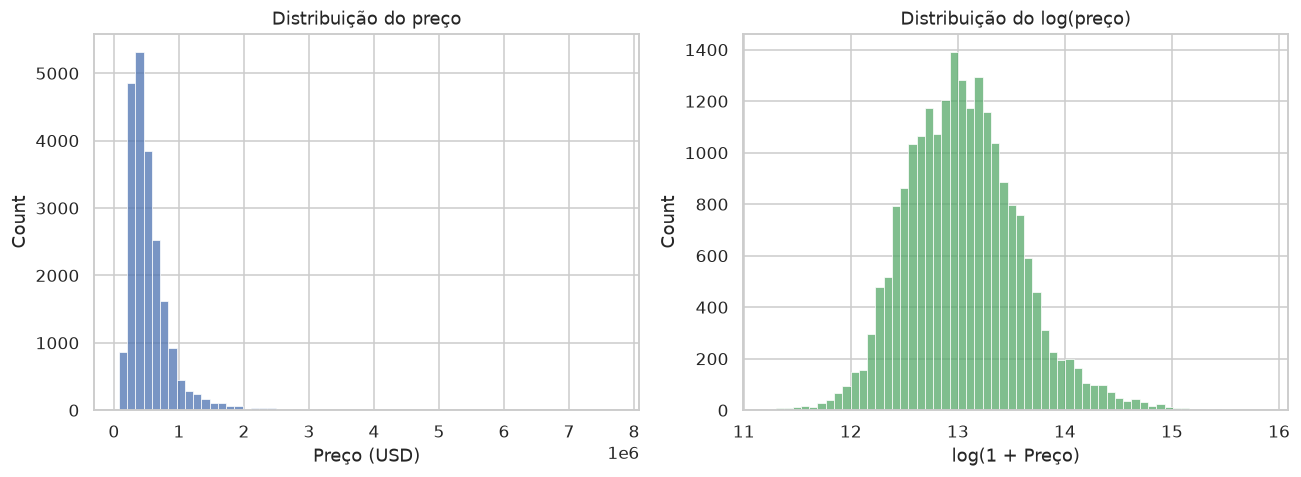

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(houses["price"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição do preço")
axes[0].set_xlabel("Preço (USD)")

sns.histplot(np.log1p(houses["price"]), bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("Distribuição do log(preço)")
axes[1].set_xlabel("log(1 + Preço)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/price_distribution.png", bbox_inches="tight")
plt.show()

print(houses["price"].describe())

- Preço médio: **US$ 540.088**; mediana: **US$ 450.000**.
- Faixa: de US$ 75.000 até **US$ 7,7 milhões**.
- O log(preço) tem distribuição bem mais próxima da normal, confirmando o
  comportamento típico de mercado imobiliário (cauda longa de imóveis de luxo).

## 3. Outliers e qualidade de dados

### 3.1 `bedrooms` = 33
Existe um imóvel com **33 quartos** e apenas 1.620 sqft de área construída —
fisicamente incoerente (equivaleria a ~49 sqft por quarto). É quase certamente
um erro de digitação (provavelmente "3"). Esse tipo de imóvel deve ser tratado
como outlier/erro de captura, não como um dado real de mercado.

In [6]:
outlier = houses[houses["bedrooms"] >= 10][
    ["id", "bedrooms", "bathrooms", "sqft_living", "price", "zipcode"]
]
outlier

,id,bedrooms,bathrooms,sqft_living,price,zipcode
8757,1773100755,11,3.00,3000,520000.0,98106
13314,627300145,10,5.25,4590,1148000.0,98004
15161,5566100170,10,2.00,3610,650000.0,98006
15870,2402100895,33,1.75,1620,640000.0,98103
19254,8812401450,10,3.00,2920,660000.0,98105


### 3.2 `sqft_lot` e `sqft_lot15`
Possuem caudas extremamente longas (lotes rurais de até 1,65 milhão de sqft ~ 38
acres), muito acima do imóvel urbano típico. Não são erros, mas têm efeito
desproporcional em modelos lineares — outro motivo para preferir modelos baseados
em árvore ou aplicar log/transformação nessas variáveis.

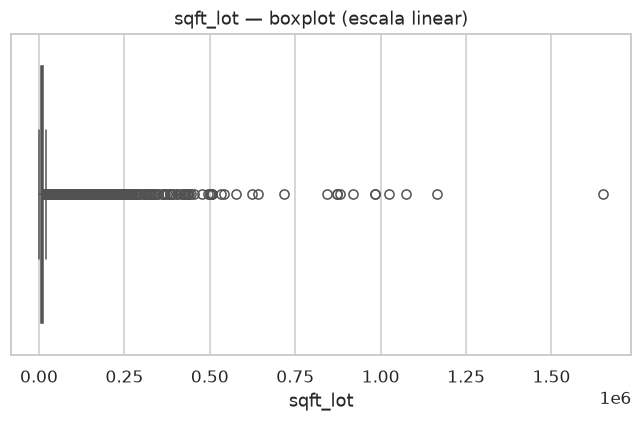

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=houses["sqft_lot"], ax=ax, color="#C44E52")
ax.set_title("sqft_lot — boxplot (escala linear)")
plt.tight_layout()
plt.savefig(f"{REPORTS}/sqft_lot_boxplot.png", bbox_inches="tight")
plt.show()

## 4. Correlação das variáveis físicas com o preço

In [8]:
numeric_cols = houses.select_dtypes(include=np.number).drop(columns=["id"])
corr = numeric_cols.corr()["price"].drop("price").sort_values(ascending=False)
corr

sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

/tmp/ipykernel_15019/1133710745.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, ax=ax, palette="viridis")


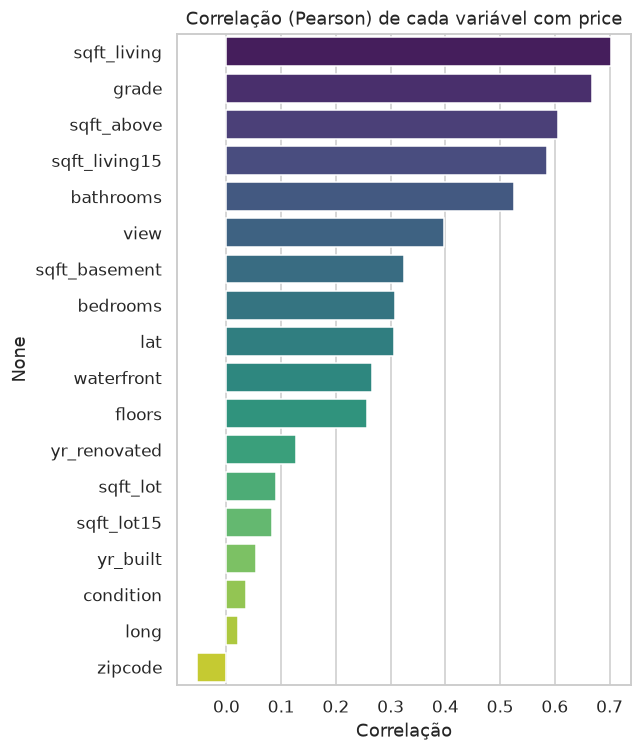

In [9]:
fig, ax = plt.subplots(figsize=(6, 7))
sns.barplot(x=corr.values, y=corr.index, ax=ax, palette="viridis")
ax.set_title("Correlação (Pearson) de cada variável com price")
ax.set_xlabel("Correlação")
plt.tight_layout()
plt.savefig(f"{REPORTS}/correlation_with_price.png", bbox_inches="tight")
plt.show()

**Principais correlações lineares com o preço:**
- `sqft_living` (0.70) — área construída é, isoladamente, o preditor mais forte.
- `grade` (0.67) — nota de qualidade de construção/acabamento.
- `sqft_above` (0.61) — área construída acima do nível do solo.
- `sqft_living15` (0.59) — padrão da vizinhança (proxy indireta de localização).
- `bathrooms` (0.53).

Correlações fracas isoladamente (`condition`, `yr_built`, `long`, `zipcode`) não
significam baixa relevância — `zipcode`, por exemplo, tem relação **não linear**
com o preço (bairros caros e baratos têm códigos numericamente próximos), por
isso sua importância real só aparece em modelos não lineares ou quando
convertido em variáveis de localização (`lat`/`long`) ou estatísticas por CEP.

## 5. Efeito de localização (lat/long e zipcode)

Plotando a localização geográfica colorida pelo preço fica evidente que o preço
depende fortemente de **onde** o imóvel está (proximidade da água e de Seattle/
Bellevue), informação que `zipcode` sozinho não captura bem para um modelo linear.

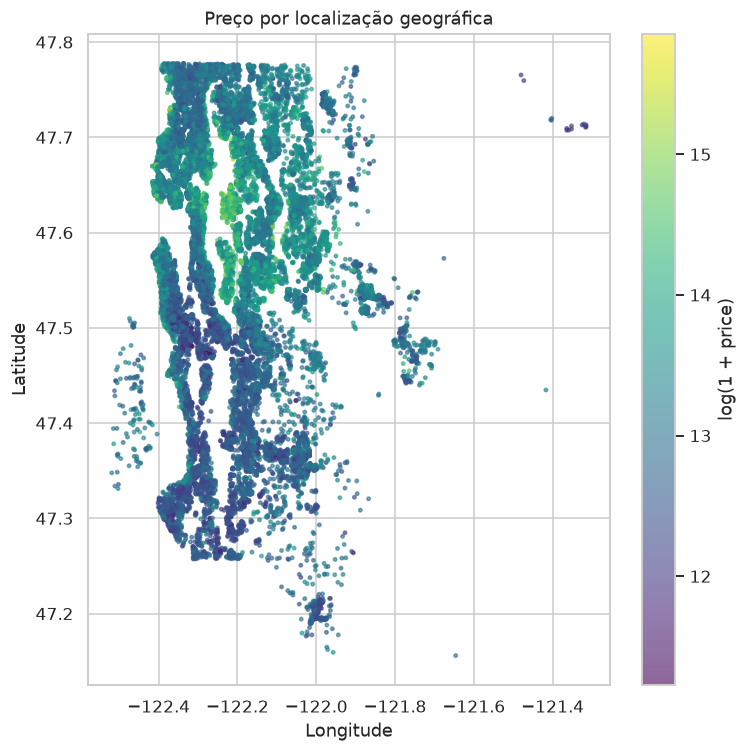

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(
    houses["long"],
    houses["lat"],
    c=np.log1p(houses["price"]),
    cmap="viridis",
    s=5,
    alpha=0.6,
)
plt.colorbar(sc, label="log(1 + price)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Preço por localização geográfica")
plt.tight_layout()
plt.savefig(f"{REPORTS}/price_by_location.png", bbox_inches="tight")
plt.show()

## 6. Combinando dados físicos com dados demográficos do CEP

`zipcode_demographics.csv` traz 26 variáveis socioeconômicas agregadas por CEP
(população, renda mediana, valor mediano dos imóveis do CEP, escolaridade), uma
linha por `zipcode`. Os **70 zipcodes** presentes em `kc_house_data.csv` têm
correspondência **1:1** com os 70 zipcodes de `zipcode_demographics.csv` — não
há CEP órfão, então o `merge` é direto (`left join` em `zipcode`, sem perda de
linhas).

In [11]:
print("Zipcodes únicos em kc_house_data:", houses["zipcode"].nunique())
print("Zipcodes únicos em zipcode_demographics:", demographics["zipcode"].nunique())
print(
    "Zipcodes sem correspondência:",
    set(houses["zipcode"]) - set(demographics["zipcode"]),
)

merged = houses.merge(demographics, on="zipcode", how="left", validate="many_to_one")
assert merged["ppltn_qty"].isna().sum() == 0
merged.shape

Zipcodes únicos em kc_house_data: 70
Zipcodes únicos em zipcode_demographics: 70
Zipcodes sem correspondência: set()


(21613, 47)

Com o merge, é possível avaliar quais variáveis demográficas mais se relacionam
com o preço (mesmo sendo uma característica do CEP, e não do imóvel individual).

In [12]:
demo_cols = [c for c in demographics.columns if c != "zipcode"]
demo_corr = (
    merged[demo_cols + ["price"]].corr()["price"].drop("price").sort_values(ascending=False)
)
demo_corr

hous_val_amt              0.579733
medn_incm_per_prsn_amt    0.549911
per_prfsnl                0.500262
per_bchlr                 0.474896
edctn_prfsnl_qty          0.291694
medn_hshld_incm_amt       0.272460
edctn_bchlr_dgre_qty      0.209238
per_urbn                  0.068983
per_sbrbn                -0.023602
sbrbn_ppltn_qty          -0.028090
per_farm                 -0.062706
per_non_farm             -0.075340
urbn_ppltn_qty           -0.093640
farm_ppltn_qty           -0.101311
non_farm_qty             -0.118589
ppltn_qty                -0.123181
edctn_some_clg_qty       -0.161619
per_some_clg             -0.188057
edctn_assoc_dgre_qty     -0.189540
per_assoc                -0.233216
edctn_less_than_9_qty    -0.245580
per_less_than_9          -0.254451
edctn_9_12_qty           -0.370619
edctn_high_schl_qty      -0.385972
per_9_to_12              -0.412200
per_hsd                  -0.494371
Name: price, dtype: float64

/tmp/ipykernel_15019/3989761922.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=demo_corr.values, y=demo_corr.index, ax=ax, palette="magma")


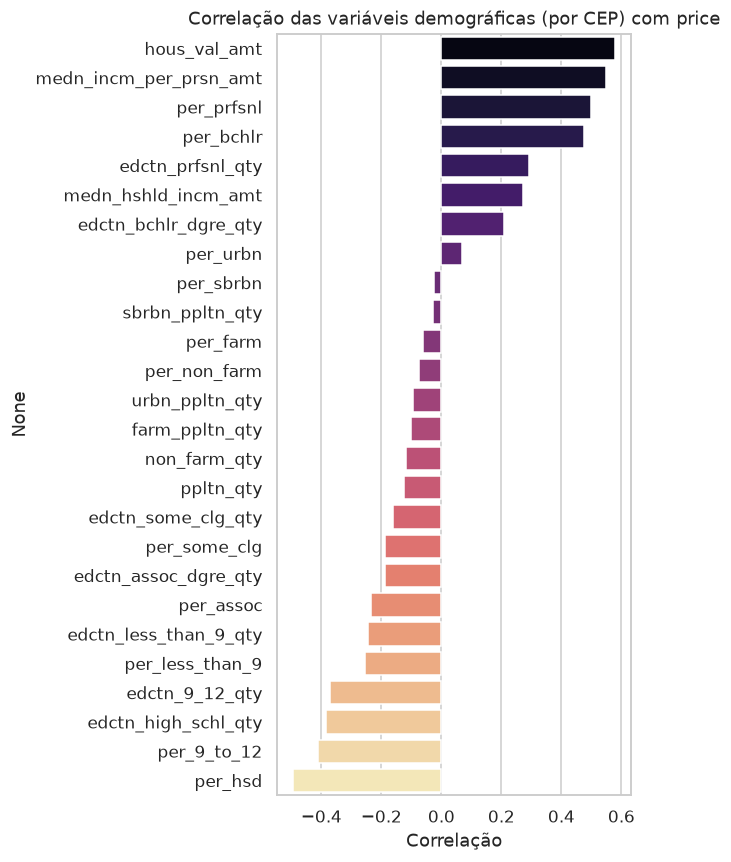

In [13]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(x=demo_corr.values, y=demo_corr.index, ax=ax, palette="magma")
ax.set_title("Correlação das variáveis demográficas (por CEP) com price")
ax.set_xlabel("Correlação")
plt.tight_layout()
plt.savefig(f"{REPORTS}/demographics_correlation.png", bbox_inches="tight")
plt.show()

**Leitura de negócio:** renda mediana do CEP (`medn_hshld_incm_amt`,
`medn_incm_per_prsn_amt`), valor mediano dos imóveis do CEP (`hous_val_amt`) e
escolaridade superior (`per_bchlr`, `per_prfsnl`) têm correlação positiva
relevante com o preço — bairros mais ricos e mais escolarizados têm imóveis mais
caros, o que é consistente com o esperado e reforça que os dados demográficos
agregam sinal complementar ao das características físicas do imóvel (que
descrevem o imóvel em si, não a vizinhança).

## 7. Conclusões da análise exploratória

1. **Tamanho construído (`sqft_living`) e qualidade de construção (`grade`)** são
   os drivers físicos mais fortes de preço.
2. **Localização** (lat/long, zipcode e as variáveis demográficas associadas)
   adiciona sinal que as variáveis puramente físicas não capturam sozinhas.
3. Existe **1 outlier claro de captura de dados** (`bedrooms = 33`) que deve ser
   corrigido ou removido antes do treino.
4. **177 imóveis vendidos duas vezes** exigem cuidado no split treino/teste
   (agrupar por `id` para evitar vazamento de dados).
5. O **merge com dados demográficos é direto** (100% de correspondência de CEP)
   e adiciona contexto socioeconômico do bairro sem custo de qualidade de dados.